<a href="https://colab.research.google.com/github/RekhaLeelara/prod-sales-forecast/blob/main/Full_Code_SuperKart_Model_Deployment_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
# #Installing the libraries with the specified versions
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
ERROR: Operation cancelled by user
^C


In [89]:
!pip install -U pip setuptools wheel

In [90]:
!pip install numpy pandas matplotlib seaborn requests

In [91]:
!pip install scikit-learn
!pip install xgboost
!pip install joblib

In [3]:
!pip install huggingface_hub

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [92]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder


# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [93]:
# Uncomment and run the following code in case Google Colab is being used
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
# Loading the dataset
boston_data = pd.read_csv('/content/drive/MyDrive/AIML/AIML_FinalData/SuperKart.csv')

In [95]:
# Create a copy of the dataframe
df = boston_data.copy()

In [96]:
# Display the first five rows of the dataset
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [97]:
# Display the column names of the dataset
df.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


# **Data Overview**

# **Exploratory Data Analysis (EDA)**

In [99]:
# Define the target variable for the regression task
target = 'Product_Store_Sales_Total'

# Let's define the numeric and categorical features
numeric_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(exclude=np.number).columns
print(f"Numerical features: {list(numeric_features)}")
print(f"Categorical features: {list(categorical_features)}")

Numerical features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical features: ['Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


In [100]:
# Generate summary statistics for numerical features
df[numeric_features].describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


	Product_Weight
  The min product weight is 4 lbs and the max product weight is 22 lbs

  Product_Allocated_Area
  The average allocated area of the product is 0.068
  
  Product_MRP	Store_Establishment_Year
  Product_Store_Sales_Total

## Univariate Analysis

In [101]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

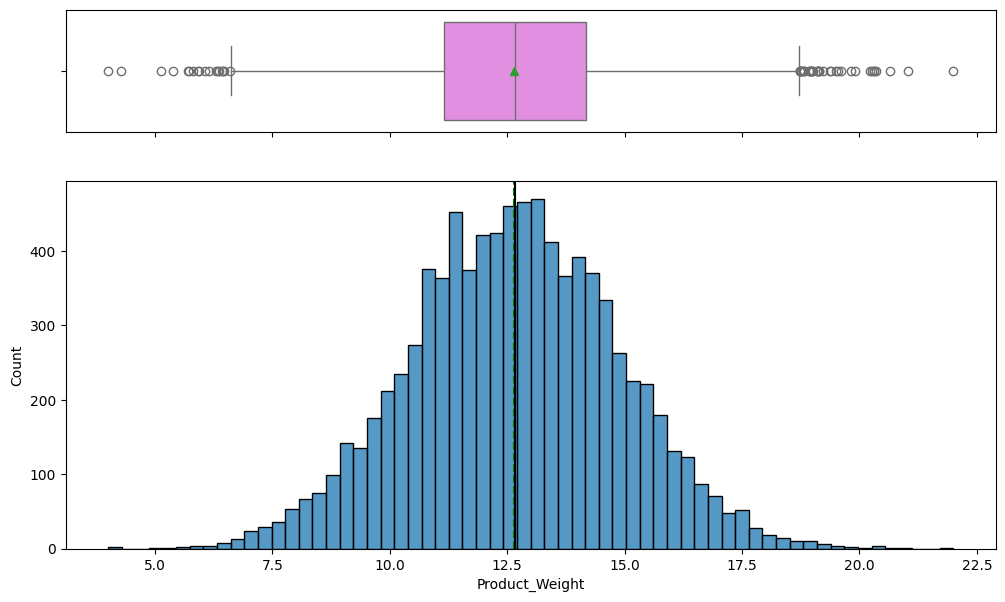

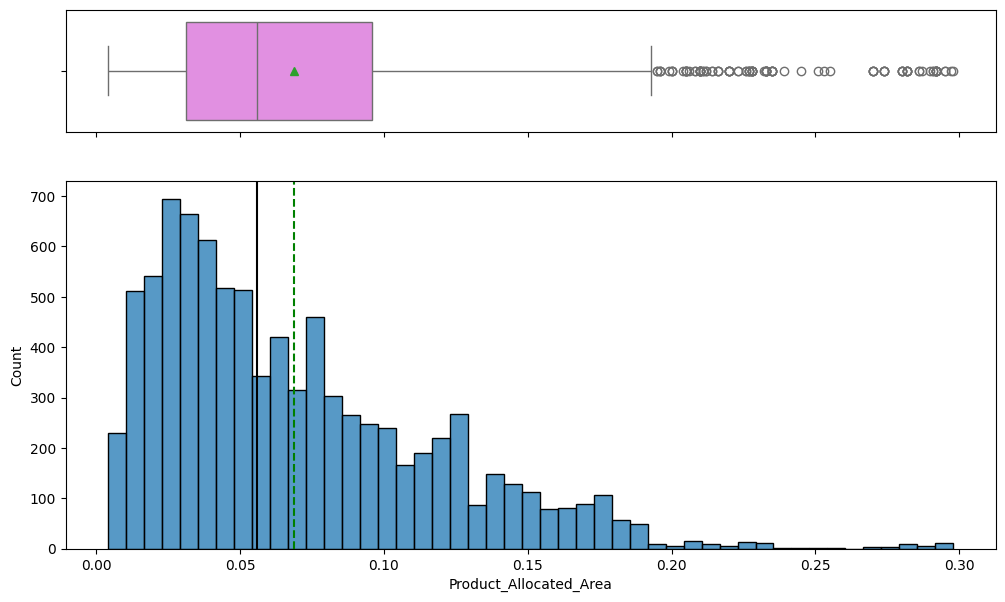

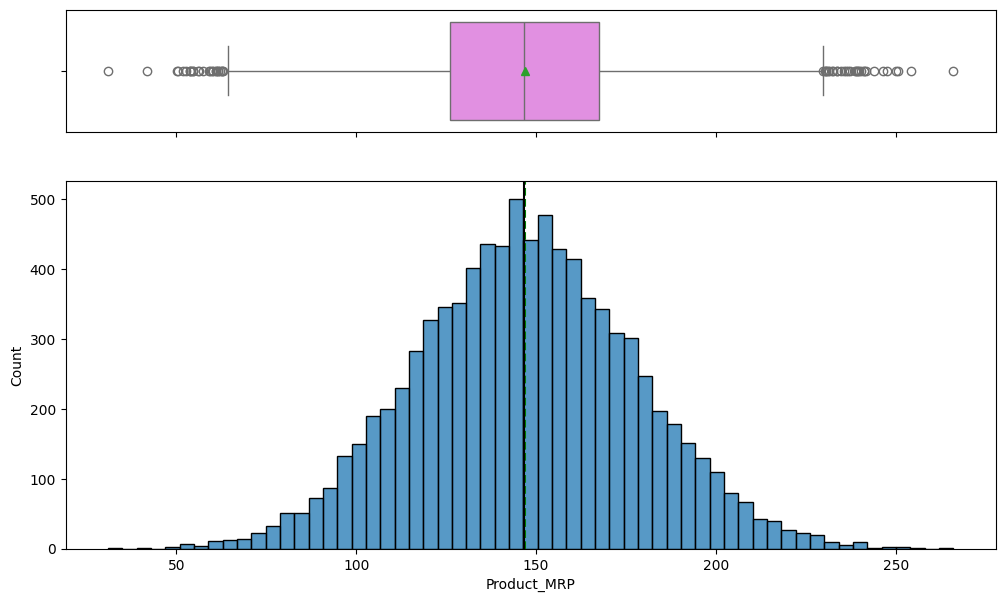

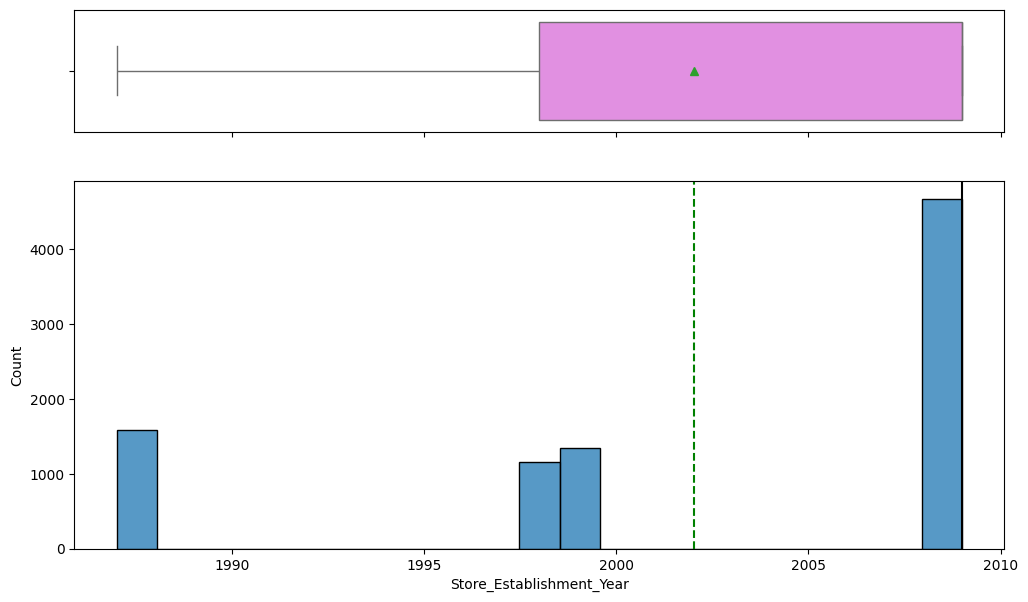

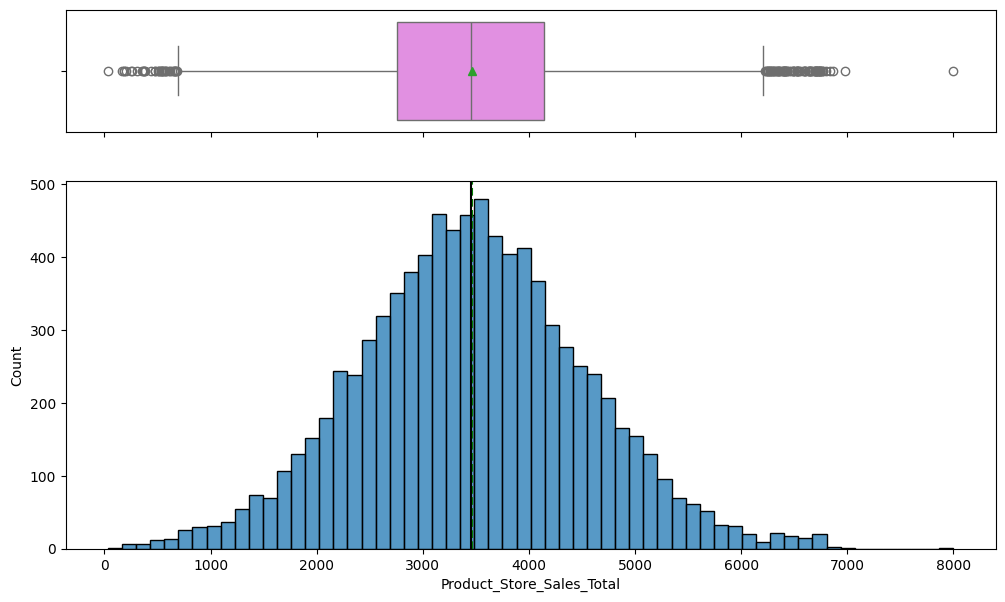

In [102]:

for feature in df.select_dtypes(include='number').columns:
    histogram_boxplot(df, feature)

In [103]:
df['Product_Store_Sales_Total'] = df['Product_Store_Sales_Total'].astype(float)

In [104]:
#Checking change in dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


Checking for duplicate values

In [105]:
# let's check for duplicate values in the data
df.duplicated().sum()

np.int64(0)

###Checking for missing values

In [106]:
# let's check for missing values in the data
round(df.isnull().sum() / df.isnull().count() * 100, 2)

,0
Product_Id,0.0
Product_Weight,0.0
Product_Sugar_Content,0.0
Product_Allocated_Area,0.0
Product_Type,0.0
Product_MRP,0.0
Store_Id,0.0
Store_Establishment_Year,0.0
Store_Size,0.0
Store_Location_City_Type,0.0


## Bivariate Analysis

Correlation Check

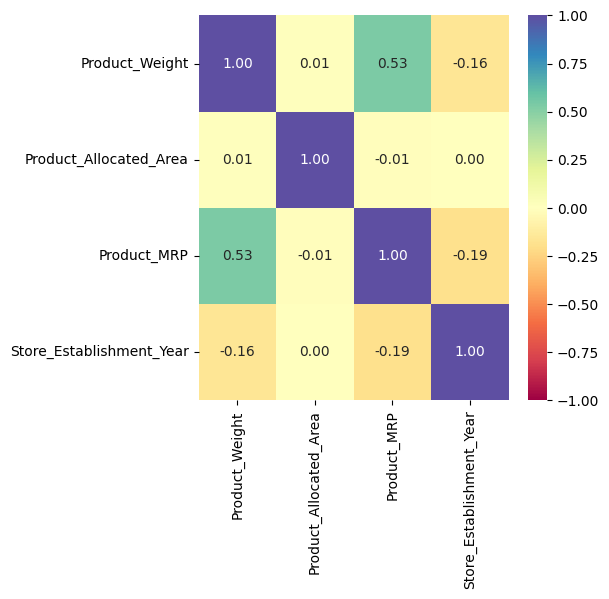

In [107]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Product_Store_Sales_Total")

plt.figure(figsize=(5, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Summary:

Feature Pair	Correlation	Interpretation
Product_Weight ↔ Product_MRP	0.53	Moderate positive correlation — heavier products tend to have higher MRP (price).

Product_Weight ↔ Product_Allocated_Area	0.01	Essentially no relationship — product weight doesn’t depend on allocated area.

Product_MRP ↔ Store_Establishment_Year	–0.19	Slight negative correlation — older stores may have slightly lower MRPs, but it’s weak.

# **Data Preprocessing**

In [108]:
# Dividing train data into X and y
X = df.drop(["Product_Store_Sales_Total"], axis=1)
y = df["Product_Store_Sales_Total"]

In [109]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [110]:
from sklearn.compose import ColumnTransformer

# Create a preprocessing pipeline for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features) # 'passthrough' is used because CHAS is already a dummy variable
    ]
)

# **Model Building**

## Define functions for Model Evaluation

In [111]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [112]:
# We'll use a pipeline to handle scaling and model training together
numeric_features_no_target = [col for col in numeric_features if col != 'Product_Store_Sales_Total']

# We will not be using OneHotEncoder as there are no categorical features.
preprocessor = make_column_transformer((StandardScaler(), numeric_features_no_target))

Creating Model Pipeline

In [113]:
# Create an XGBoost Regressor Pipeline
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

In [114]:
# Create a Random Forest Regressor Pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),          # scaling step
    ('regressor', RandomForestRegressor(random_state=42))
])

Model Training

In [115]:
# Fit the model
xgb_model.fit(X_train, y_train)

# Evaluate model performance on the test set
xgb_test_performance = model_performance_regression(xgb_model, X_test, y_test)

# print("Random Forest Test Performance:\n", rf_test_performance)
print("\nXGBoost Test Performance:\n", xgb_test_performance)


XGBoost Test Performance:
          RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  300.239876  131.67726   0.920997        0.920498  0.048494


In [116]:
# Fit the model
rf_model.fit(X_train, y_train)

# Evaluate model performance on the test set
rf_test_performance = model_performance_regression(rf_model, X_test, y_test)

# Print results
print("\nRandom Forest Test Performance:\n", rf_test_performance)



Random Forest Test Performance:
          RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  291.552989  110.441274   0.925502        0.925032  0.039955


# **Model Performance Improvement - Hyperparameter Tuning**

In [117]:
param_grid_xgb = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.7, 0.8, 0.9]
}

# Use GridSearchCV to find the best parameters
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train, y_train)

print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
best_xgb_model = grid_search_xgb.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters for XGBoost: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 7, 'regressor__n_estimators': 100, 'regressor__subsample': 0.7}


In [118]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_features': ['sqrt']
}


# Use GridSearchCV to find the best parameters
grid_search_rf = GridSearchCV(
    rf_model,                      # your Random Forest pipeline
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search_rf.fit(X_train, y_train)

# Display best parameters and best model
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
best_rf_model = grid_search_rf.best_estimator_


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for Random Forest: {'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [119]:
# Evaluate tuned models
best_xgb_test_performance = model_performance_regression(best_xgb_model, X_test, y_test)
best_rf_test_performance  = model_performance_regression(best_rf_model, X_test, y_test)

# Compare performance
comparison_df = pd.concat(
    [best_xgb_test_performance, best_rf_test_performance],
    ignore_index=True
)

comparison_df['Model'] = ['Tuned XGBoost', 'Tuned Random Forest']

print("Model Performance Comparison:\n", comparison_df)

# Select final model
final_model = best_xgb_model if comparison_df.loc[0, 'RMSE'] < comparison_df.loc[1, 'RMSE'] else best_rf_model


Model Performance Comparison:
          RMSE         MAE  R-squared  Adj. R-squared      MAPE  \
0  289.279517  115.507409   0.926660        0.926196  0.043015   
1  286.101222  113.583729   0.928263        0.927809  0.044119   

                 Model  
0        Tuned XGBoost  
1  Tuned Random Forest  


In [120]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [121]:
# Define the file paths to save (serialize) the trained regression model
saved_model_path = "backend_files/superkart_model.joblib"

In [122]:
# Save the trained regression model and preprocessor using joblib
joblib.dump(final_model, saved_model_path)
# joblib.dump(preprocessor, saved_preprocessor_path)
print("\nFinal regression model and preprocessor saved successfully.")


Final regression model and preprocessor saved successfully.


In [123]:
# Load the saved regression model and preprocessor from the files
loaded_model = joblib.load(saved_model_path)
# loaded_preprocessor = joblib.load(saved_preprocessor_path)

In [124]:
# Make predictions on the test set
y_pred_test = loaded_model.predict(X_test)
y_pred_test

array([3407.80932385, 3360.7419671 , 2431.03061171, ..., 4106.54236189,
       2893.01956464, 4522.65326341])

In [125]:
# from sklearn.metrics import mean_squared_error, r2_score
print(mean_squared_error(y_test, y_pred_test))
print(r2_score(y_test, y_pred_test))


81853.9094945732
0.9282625107948835


In [126]:
loaded_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year'])])),
                ('regressor',
                 RandomForestRegressor(max_features='sqrt', min_samples_split=5,
                                       random_state=42))])

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [127]:
%%writefile backend_files/app.py
import joblib
import pandas as pd
from flask import Flask, request, jsonify

# Initialize Flask app
app = Flask("Sales Forecast Predictor ")

# Load the trained Boston housing model
loaded_model = joblib.load("superkart_model.joblib")

# Define a route for the home page
@app.get('/')
def home():
    return "Welcome to the Sales Forecast Prediction API!"

# Define an endpoint to predict price for a single house
@app.post('/v1/Sales')
def predict_sales_price():
    # Get JSON data from the request
    salesprice_data = request.get_json()

    # Extract relevant house features from the input data
    sample = {
        'Product_Id': salesprice_data['Product_Id'],
        'Product_Weight': salesprice_data['Product_Weight'],
        'Product_Sugar_Content': salesprice_data['Product_Sugar_Content'],
        'Product_Allocated_Area': salesprice_data['Product_Allocated_Area'],
        'Product_Type': salesprice_data['Product_Type'],
        'Product_MRP': salesprice_data['Product_MRP'],
        'Store_Id': salesprice_data['Store_Id'],
        'Store_Establishment_Year': salesprice_data['Store_Establishment_Year'],
        'Store_Size': salesprice_data['Store_Size'],
        'Store_Location_City_Type': salesprice_data['Store_Location_City_Type'],
        'Store_Type': salesprice_data['Store_Type'],
        'Product_Store_Sales_Total': salesprice_data['Product_Store_Sales_Total']
    }
    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Predicted_Product_Store_Sales_Total': prediction})

# Define an endpoint to predict price for a batch of Products
@app.post('/v1/salesforecast')
def predict_house_batch():
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the file into a DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for the batch data
    predictions = model.predict(input_data).tolist()

    # Add predictions to the DataFrame
    input_data['Predicted_Product_Store_Sales_Total'] = predictions

    # Convert results to dictionary
    result = input_data.to_dict(orient="records")

    return jsonify(result)

# Run the Flask app in debug mode
if __name__ == '__main__':
    app.run(debug=True)

Overwriting backend_files/app.py


## Dependencies File

In [128]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]

Overwriting backend_files/requirements.txt


## Dockerfile

In [129]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:app"]

Overwriting backend_files/Dockerfile


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [130]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [131]:
df.describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


In [132]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests

BACKEND_URL = "http://backend:7860"

st.title("SuperKart Product Sales Forecast App")
st.write("Predict product sales based on key product and store features.")

# Load dataset to populate selectboxes
df = pd.read_csv("SuperKart.csv")

# Numeric sliders (ranges based on typical retail values; adjust if needed)
Product_Weight = st.slider("Product Weight", 4.0, 22.0, 50.0)
Product_Sugar_Content = st.slider("Product Sugar Content", 0.0, 100.0, 10.0)
Product_Allocated_Area = st.slider("Product Allocated Area", 0.004, 2000.0, 100.0)
Product_MRP = st.slider("Product MRP", 0.0, 5000.0, 100.0)
Store_Establishment_Year = st.slider("Store Establishment Year", 1950, 2025, 2000)

# Categorical selectboxes (values taken directly from your dataset)
Product_Id = st.selectbox("Product ID", df["Product_Id"].unique())
Product_Type = st.selectbox("Product Type", df["Product_Type"].unique())
Store_Id = st.selectbox("Store ID", df["Store_Id"].unique())
Store_Size = st.selectbox("Store Size", df["Store_Size"].unique())
Store_Location_City_Type = st.selectbox("Store Location City Type", df["Store_Location_City_Type"].unique())
Store_Type = st.selectbox("Store Type", df["Store_Type"].unique())

# Build input JSON
input_data = {
    "Product_Id": Product_Id,
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_Type": Product_Type,
    "Product_MRP": Product_MRP,
    "Store_Id": Store_Id,
    "Store_Establishment_Year": Store_Establishment_Year,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type
}

# Prediction button
if st.button("Predict", type='primary'):
    response = requests.post(f"{BACKEND_URL}/v1/sales", json=input_data)

    if response.status_code == 200:
        result = response.json()
        predicted_sales = result["Predicted_Sales"]
        st.success(f"Predicted Sales Forecast: **{predicted_sales:.2f}**")
    else:
        st.error("Error in API request")

# Batch Prediction
st.subheader("Batch Prediction")
file = st.file_uploader("Upload CSV file", type=["csv"])

if file is not None:
    if st.button("Predict for Batch", type='primary'):
        response = requests.post(
            f"{BACKEND_URL}/v1/salesbatch",
            files={"file": file}
        )

        if response.status_code == 200:
            result = response.json()
            st.header("Batch Prediction Results")
            st.write(result)
        else:
            st.error("Error in API request")

print(Product_Id)


Overwriting frontend_files/app.py


## Dependencies File

In [133]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting frontend_files/requirements.txt


## Dockerfile

In [134]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Overwriting frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

In [135]:
# Your GitHub Personal Access Token

from google.colab import userdata
GITHUB_TOKEN = userdata.get('Gittoken')  # Replace with the secret name. For example, Gittoken

# After executing this code, you may be prompted to grant access. Click **Grant Access** to continue.

In [136]:
!pip install PyGithub

In [138]:
%%writefile docker-compose.yml
version: "3.9"

services:
  backend:
    build: ./backend
    container_name: backend
    ports:
      - "7860:7860"

  frontend:
    build: ./frontend
    container_name: frontend
    ports:
      - "8501:8501"
    depends_on:
      - backend

Overwriting docker-compose.yml


In [139]:
# Name for the new repository
REPO_NAME = "prod-sales-forecast"  # Change this if you want a different name

# Authenticate with GitHub
from github import Github

g = Github(GITHUB_TOKEN)
user = g.get_user()
print(f"Authenticated as: {user.login}")

# Create the repository
repo = user.create_repo(
    REPO_NAME,
    description="Product sales forecast - Flask API Backend + Streamlit Frontend (Dockerized)",
    private=False,
    auto_init=True  # Creates an initial README so the repo is not empty
)

print(f"Repository created successfully: {repo.html_url}")

# Dictionary mapping repo file paths to local file paths
# Backend files go under backend/ and frontend files go under frontend/
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/superkart_model.joblib": "backend_files/superkart_model.joblib",

    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",

    # ⭐ CSV included correctly
    "frontend/SuperKart.csv": "frontend_files/SuperKart.csv",

    # ⭐ Compose file included correctly
    "docker-compose.yml": "docker-compose.yml"
}

# Upload all files
for repo_path, local_path in files_to_push.items():
    with open(local_path, "rb") as f:
        content = f.read()

    repo.create_file(
        path=repo_path,
        message=f"Add {repo_path}",
        content=content,
        branch="main"
    )
    print(f"Uploaded: {repo_path}")

print(f"\nAll files pushed successfully to: {repo.html_url}")

Authenticated as: RekhaLeelara
Repository created successfully: https://github.com/RekhaLeelara/prod-sales-forecast
Uploaded: backend/app.py
Uploaded: backend/requirements.txt
Uploaded: backend/Dockerfile
Uploaded: backend/superkart_model.joblib
Uploaded: frontend/app.py
Uploaded: frontend/requirements.txt
Uploaded: frontend/Dockerfile
Uploaded: frontend/SuperKart.csv
Uploaded: docker-compose.yml

All files pushed successfully to: https://github.com/RekhaLeelara/prod-sales-forecast


In [140]:
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".joblib"):
            print(os.path.join(root, file))

./drive/MyDrive/AIML/ModelDeployment/churn_prediction_model_v1_0.joblib
./backend_files/superkart_model.joblib


# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [142]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [160]:
model_root_url = "https://organic-couscous-q4r7vx9jj5w2xjj7-7860.app.github.dev"  # Replace with your Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [161]:
model_url = model_root_url + "/v1/sales" # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [162]:
model_batch_url = model_root_url + "/v1/salesforecast"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

In [163]:
import requests
print(requests.get(model_root_url).text)

Welcome to the Sales Forecast Prediction API!


## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [164]:
payload = {
    "Product_Id": "FD6114",
    "Product_Weight": 12.66,
    "Product_Sugar_Content": "Low Sugar",
    "Product_Allocated_Area": 0.027,
    "Product_Type": "Frozen Foods",
    "Product_MRP": 117.08,
    "Store_Id": "OUT004",
    "Store_Establishment_Year": 2009,
    "Store_Size": "Medium",
    "Store_Location_City_Type": "Tier 2",
    "Store_Type": "Supermarket Type2",
}

In [165]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [166]:
response

<Response [200]>

In [167]:
print(model_url)  # or model_batch_url, if this was the batch cell
print(response.status_code)
print(response.headers.get("server"), response.headers.get("content-type"))
print(response.text[:500])

https://organic-couscous-q4r7vx9jj5w2xjj7-7860.app.github.dev/v1/sales
200
None application/json
{"Predicted_Sales":2912.3920934920643}



`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [168]:
print(response.json())

{'Predicted_Sales': 2912.3920934920643}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [172]:
full = pd.read_csv('/content/drive/MyDrive/AIML/AIML_FinalData/SuperKart.csv')
batch_dataset = full.sample(10, random_state=42).drop(columns=['Product_Store_Sales_Total'])
batch_dataset.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type
1226,FD1781,12.53,Regular,0.066,Snack Foods,145.62,OUT004,2009,Medium,Tier 2,Supermarket Type2
7903,FD3171,13.29,Low Sugar,0.086,Canned,135.99,OUT004,2009,Medium,Tier 2,Supermarket Type2
1559,FD1479,9.99,Regular,0.090,Fruits and Vegetables,125.79,OUT001,1987,High,Tier 2,Supermarket Type1
3621,NC4402,10.72,No Sugar,0.049,Health and Hygiene,92.94,OUT002,1998,Small,Tier 3,Food Mart
7552,DR433,15.60,Low Sugar,0.121,Soft Drinks,176.07,OUT001,1987,High,Tier 2,Supermarket Type1


**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [173]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [174]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [175]:
response

<Response [200]>

In [176]:
# Extract predictions from API response
response.text

'[{"Predicted_Sales":3407.8093238492083,"Product_Allocated_Area":0.066,"Product_Id":"FD1781","Product_MRP":145.62,"Product_Sugar_Content":"Regular","Product_Type":"Snack Foods","Product_Weight":12.53,"Store_Establishment_Year":2009,"Store_Id":"OUT004","Store_Location_City_Type":"Tier 2","Store_Size":"Medium","Store_Type":"Supermarket Type2"},{"Predicted_Sales":3360.7419671031753,"Product_Allocated_Area":0.086,"Product_Id":"FD3171","Product_MRP":135.99,"Product_Sugar_Content":"Low Sugar","Product_Type":"Canned","Product_Weight":13.29,"Store_Establishment_Year":2009,"Store_Id":"OUT004","Store_Location_City_Type":"Tier 2","Store_Size":"Medium","Store_Type":"Supermarket Type2"},{"Predicted_Sales":2431.0306117063487,"Product_Allocated_Area":0.09,"Product_Id":"FD1479","Product_MRP":125.79,"Product_Sugar_Content":"Regular","Product_Type":"Fruits and Vegetables","Product_Weight":9.99,"Store_Establishment_Year":1987,"Store_Id":"OUT001","Store_Location_City_Type":"Tier 2","Store_Size":"High","St

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

-

-